# 🧭 Notebook 04 — Learning by Stumbling: Q-Learning

**Series**: RL Notebook Series · Act II — Value-Based Methods · Post 4 of 15

---

## What You'll Learn

In Notebook 03, we solved the environment using Dynamic Programming. But there was a catch: we needed a **crystal ball** — the full transition model $P(s'|s,a)$. The agent didn't have to explore; it could just pull out the blueprint of the universe and compute the answer.

Real life isn't like that. You don't know the probabilities of every outcome, or where all the rewards are. You have to try things.

Welcome to **Model-Free Reinforcement Learning**.

By the end, you'll understand:

1. **The Action-Value Function ($Q$)** — why learning $V(s)$ isn't enough when you don't have the model
2. **Explore vs. Exploit** — learning by trying bad ideas ($\\epsilon$-greedy)
3. **Temporal Difference (TD) Learning** — updating a guess with another guess
4. **Q-Learning** — one of the most famous and foundational RL algorithms ever invented


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

%matplotlib inline
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3})
np.random.seed(42)

from utils.envs import GridEnvironment
from utils.plotting import plot_values_grid, plot_policy_arrows, plot_rewards, plot_comparison

## 1. Model-Free RL: No Crystal Ball

When you don't know $P$, you can't compute the Bellman expectation $\sum P(s') V(s')$. You can only call `env.step(action)` and see what happens.

Let's say we learned the perfect state-value function $V^*(s)$. You are in state `A`. You know its value is `10`. What action do you take?

...You don't know! Without $P$, measuring *how good the current state is* doesn't tell you *how to leave it*.

This is why model-free RL algorithms almost exclusively learn the **Action-Value function**, $Q(s,a)$. If you know $Q(s,a)$ for all actions, picking the best one is trivial: just take `argmax_a Q(s,a)`.

## 2. The Exploration-Exploitation Dilemma

To learn $Q$, the agent has to try actions. But if it always picks the action that currently looks best (**exploitation**), it might get stuck taking a safe, boring route and never find the massive jackpot hidden in the corner (**exploration**).

We need a policy that balances both. The standard simple approach is **$\\epsilon$-greedy** (epsilon-greedy):

- With probability $1 - \\epsilon$: Take the greedy action (exploitation)
- With probability $\\epsilon$: Take a completely random action (exploration)

In [2]:
def epsilon_greedy_policy(Q, state, epsilon, n_actions):
    """
    Choose an action based on epsilon-greedy strategy.

    Args:
        Q:         The Q-table, shape (n_states, n_actions)
        state:     The current state index
        epsilon:   Probability of taking a random action [0.0, 1.0]
        n_actions: Number of possible actions

    Returns:
        action: int
    """
    if np.random.random() < epsilon:
        # Explore
        return np.random.randint(n_actions)
    else:
        # Exploit: best action (break ties randomly for fairness)
        q_values = Q[state]
        best_q = np.max(q_values)
        best_actions = np.where(q_values == best_q)[0]
        return np.random.choice(best_actions)

In [3]:
Q_dummy = np.array([[0.1, 0.5, 0.2, 0.9]]) # 1 state, 4 actions

np.random.seed(42)
actions_0   = [epsilon_greedy_policy(Q_dummy, 0, 0.0, 4) for _ in range(1000)]
actions_0_1 = [epsilon_greedy_policy(Q_dummy, 0, 0.1, 4) for _ in range(1000)]

print(f"\\epsilon=0.0 (greedy) picks best action {actions_0.count(3)}/1000 times.")
expected_0_1 = int(1000 * 0.9 + 1000 * 0.1 * 0.25) # 90% greedy + 10% random (where 1/4 is the best)
print(f"\\epsilon=0.1 picks best action {actions_0_1.count(3)}/1000 times (expect ~{expected_0_1}).")

\epsilon=0.0 (greedy) picks best action 1000/1000 times.
\epsilon=0.1 picks best action 922/1000 times (expect ~925).


## 3. Temporal Difference (TD) Learning

How do we update our $Q$ estimates after a step? We use **Temporal Difference** learning.

Imagine you are predicting the weather for Saturday on Wednesday. On Thursday, you have more information, so you update your Wednesday prediction. You are updating a guess using a *better guess* made later in time.

In Q-Learning, the TD update rule is:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \big[ R + \gamma \max_{a'} Q(s',a') - Q(s,a) \big]$$

Let's break that down:
- $R + \gamma \max_{a'} Q(s',a')$: The **TD Target**. What we *now* think the total return is, having seen the immediate reward and moved to state $s'$.
- $Q(s,a)$: The **Old Prediction**.
- $R + \gamma \max_{a'} Q(s',a') - Q(s,a)$: The **TD Error**. The difference between our new guess and old guess.
- $\alpha$: The **Learning Rate** [0,1]. How much of the error we accept. (1.0 = overwrite completely, 0.1 = nudge slightly).

> *"TD learning is an update where the agent learns from its own subsequent estimates."* — Sutton & Barto

## 4. Writing the Q-Learning Training Loop

Let's put it all together. Q-Learning is an **off-policy** algorithm: it evaluates the optimal (greedy) policy while actually following an exploratory ($\\epsilon$-greedy) policy.

In [4]:
def q_learning(env, num_episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1):
    """
    Train an agent using the Q-Learning algorithm.

    Args:
        env:          The environment
        num_episodes: Number of episodes to run
        alpha:        Learning rate
        gamma:        Discount factor
        epsilon:      Exploration rate

    Returns:
        Q:            The learned Q-table
        rewards:      List of total rewards obtained per episode
    """
    # Initialize Q-table with zeros
    Q = np.zeros((env.n_states, env.n_actions))
    rewards_history = []

    for ep in range(num_episodes):
        state = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < 100:  # cap max steps to prevent infinite loops
            # 1. Choose action using epsilon-greedy
            action = epsilon_greedy_policy(Q, state, epsilon, env.n_actions)

            # 2. Take action, observe outcome
            next_state, reward, done, _ = env.step(action)

            # 3. Compute TD Target
            if done:
                td_target = reward
            else:
                td_target = reward + gamma * np.max(Q[next_state])

            # 4. Compute TD Error and Update Q
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state = next_state
            total_reward += reward
            steps += 1

        rewards_history.append(total_reward)

    return Q, rewards_history

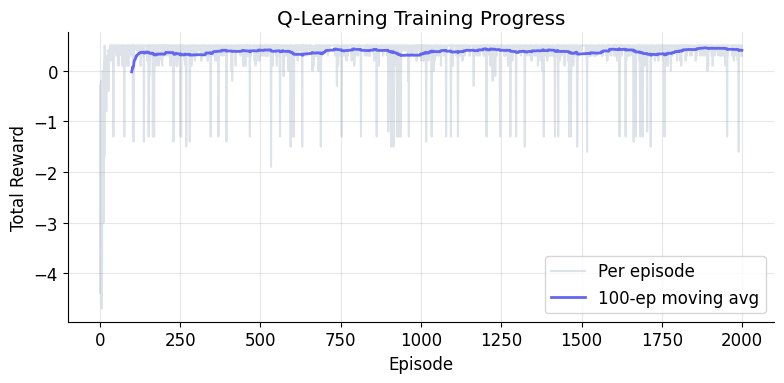

In [5]:
env = GridEnvironment(
    rows=4, cols=4,
    start=(0, 0), goal=(3, 3),
    walls=[(1, 1)], traps=[(1, 3), (3, 0)],
    stochastic=False
)

Q_learned, rewards = q_learning(env, num_episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1)

fig, ax = plt.subplots(figsize=(8, 4))
plot_rewards(rewards, window=100, title="Q-Learning Training Progress", ax=ax)
plt.show()

## 5. Did it learn the optimal path?

Look at the reward curve above: it starts out terrible (lots of negative rewards from falling into traps or wandering aimlessly). Eventually, the agent discovers the goal, the reward signal propagates backward, and the agent learns to trace the optimal path consistently.

To extract $V(s)$ and $\pi(s)$ from the $Q$-table, we simply extract the max and argmax across the action axis.

Learned V(start): 0.181
From DP (Notebook 03), Optimal V(start) is 0.181


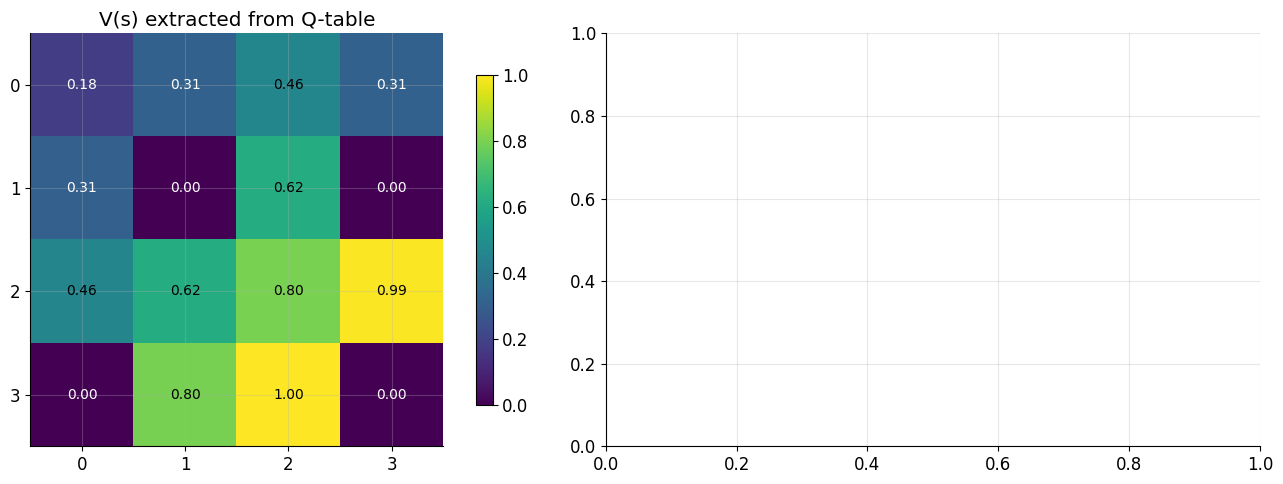

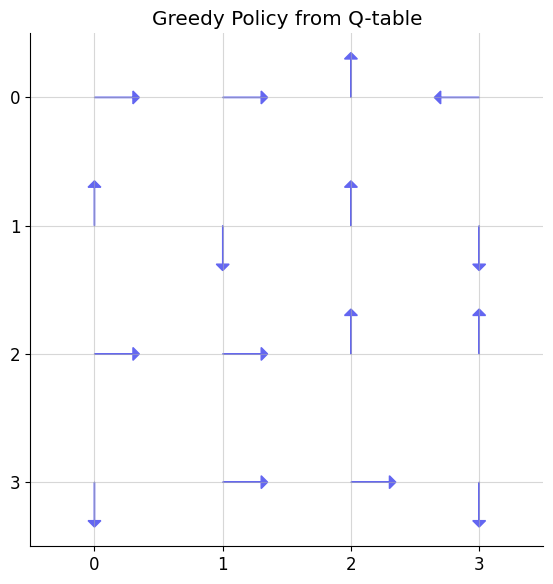

In [6]:
# Extract V(s) and policy from Q-table
V_learned = np.max(Q_learned, axis=1)
policy_learned = np.argmax(Q_learned, axis=1)

print(f"Learned V(start): {V_learned[0]:.3f}")
print("From DP (Notebook 03), Optimal V(start) is 0.181")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_values_grid(V_learned, (4, 4), title="V(s) extracted from Q-table", ax=axes[0])
plot_policy_arrows(policy_learned, (4, 4), title="Greedy Policy from Q-table")
plt.show()

## 6. The Impact of Epsilon

What happens if we never explore? What if we explore too much?
Let's run three agents with different $\\epsilon$ values and compare them.

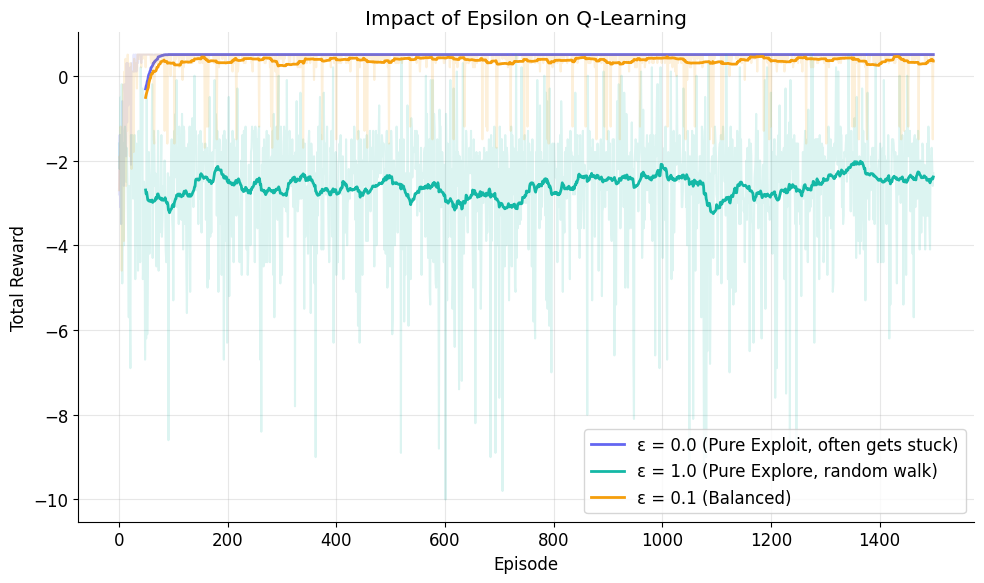

In [7]:
np.random.seed(1)
_, rewards_greedy  = q_learning(env, num_episodes=1500, epsilon=0.0)
_, rewards_explore = q_learning(env, num_episodes=1500, epsilon=1.0)
_, rewards_bal     = q_learning(env, num_episodes=1500, epsilon=0.1)

comparison = {
    'ε = 0.0 (Pure Exploit, often gets stuck)': rewards_greedy,
    'ε = 1.0 (Pure Explore, random walk)': rewards_explore,
    'ε = 0.1 (Balanced)': rewards_bal
}

plot_comparison(comparison, window=50, title="Impact of Epsilon on Q-Learning")
plt.show()

### Epsilon Decay
Notice that the balanced curve (`0.1`) learns fast, but it never reaches a *perfect* average reward because it continues taking random actions 10% of the time, occasionally walking into a wall or taking longer paths.

In practice, RL practitioners use **epsilon decay**: start high (e.g., $\\epsilon=1.0$) to explore everything, then gradually lower it to a very small number (e.g., $\\epsilon=0.01$) so the agent eventually stops exploring and just exploits its excellent knowledge.

## 7. The Limits of Tabular Q-Learning

We have solved Model-Free RL! This exact algorithm is mathematically guaranteed to converge to the optimal policy, given enough time and exploration.

So why isn't RL a solved problem? Why did it take until 2013 for DeepMind to beat Atari games?

Because of the `Q` table structure (`np.zeros((env.n_states, env.n_actions))`).

1. **Storage:** An Atari frame has $256^{7056}$ possible combinations. You cannot fit a table with that many rows into RAM. The universe doesn't have enough atoms.
2. **Generalisation:** In a table, State 1 and State 2 are completely disconnected. If we learn that $Q(S_1, \text{jump}) = 100$, and we encounter $S_2$ which is *one pixel different*, tabular Q-Learning has to start learning about $S_2$ from absolute scratch.

### The Fix: Deep Q-Networks (DQN)

Instead of storing $Q(s,a)$ in a colossal table, what if we train a **Neural Network** to predict it?

$$f_{\theta}(s, a) \approx Q(s,a)$$

Neural networks compress information and generalise. If the net learns jumping is good when a Goomba is near Mario, it will recognise the Goomba even if it's shifted by two pixels.

That is exactly what we will build in **Notebook 05**.